# E E 344 — Data-Driven Modeling And Machine Learning Assignment 2
## Five parts
1. Q1: Outlier Detection and Removal using Cook’s Distance
2. Q2 Train/Test Evaluation Before vs After Outlier Removal
3. Q3 Reliability of Coefficients (Use Outlier-Removed Dataset)
4. Q4 Most Important vs Least Important Features (Use Outlier-Removed Dataset)
5. Q5 Regularization Paths (Scaled Data, Outlier-Removed Dataset)


In [ ]:
# === Imports ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import OLSInfluence

from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

import statsmodels.api as sm

In [27]:
# === Load dataset ===
DATA_PATH = "usina_with_outliers.csv"
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
display(df.head())

target_col = df.columns[-1] 
print("Target column:", target_col)

Shape: (9568, 5)


,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


Target column: PE


# Q1: Outlier Detection and Removal using Cook’s Distance
## Model choices: Linear regression
- Cook’s Distance is a classical influence measure that is explicitly derived for the OLS framework, removing a single observation on the fitted coefficients can be analytically characterized. Using linear regression allows Cook’s Distance is best for measure how much an individual data point influences the estimated regression coefficients.
## Library choices: Statsmodels OLS
- Statsmodels has built-in influence diagnostics, including Cook’s Distance and leverage values. This is convinient for identifying influential observations without requiring custom implementations of the hat matrix or residual-based influence measures.
## What this code does:
1. Compute Cook’s Distance for each data point.
2. Identify outliers using an appropriate threshold rule (you may use standard rules such as 4/n or justify your own).
3. Remove the detected outliers and create a new DataFrame without outliers.
4. Export the cleaned dataset to a new CSV file named exactly: usina.csv


In [ ]:
def fit_ols_diagnostics(X, y):
    """Fit OLS and return (model, diagnostics dataframe).

    Parameters
    ----------
    X : array-like, shape (n,) or (n, p)
        Feature matrix (without intercept column).
    y : array-like, shape (n,)
        Target vector.
    """
    X = np.asarray(X)
    y = np.asarray(y).reshape(-1)
    if X.ndim == 1:
        X = X.reshape(-1, 1)

    # Add intercept column for statsmodels
    X_sm = sm.add_constant(X)
    model = sm.OLS(y, X_sm).fit()

    infl = OLSInfluence(model)
    diag = pd.DataFrame({
        "y": y,
        "y_hat": model.fittedvalues,
        "residual": model.resid,
        "leverage_hii": infl.hat_matrix_diag,
        "cooks_D": infl.cooks_distance[0]
    })
    return model, diag

In [ ]:
model_full, diag_full = fit_ols_diagnostics(X, y)
n = len(df)
threshold = 4 / n

diag_table = diag_full.copy()
diag_table["flag_D_gt_4_over_n"] = diag_table["cooks_D"] > threshold

print(f"Cook's distance heuristic threshold 4/n = {threshold:.6f}")
print("Top 10 points by Cook's D:")
display(diag_table.sort_values("cooks_D", ascending=False).head(10))

# Remove ALL outliers above threshold
outlier_mask = diag_table["flag_D_gt_4_over_n"].to_numpy()
outlier_indices = np.where(outlier_mask)[0]
print(f"Outliers flagged (Cook's D > 4/n): {len(outlier_indices)} out of {n}")
df_clean = df[~outlier_mask].reset_index(drop=True)

# Export cleaned dataset
df_clean.to_csv("usina.csv", index=False)
print("Saved cleaned dataset to: usina.csv")
print(f"Clean dataset size: {len(df_clean)}")


Cook's distance heuristic threshold 4/n = 0.000418
Top 10 points by Cook's D:


,y,y_hat,residual,leverage_hii,cooks_D,flag_D_gt_4_over_n
4228,532.89197,367.627618,165.264352,0.027485,1.283760,True
49,370.64803,515.833750,-145.185720,0.027817,1.003422,True
875,541.43197,408.524788,132.907182,0.032505,0.992133,True
5922,373.10803,481.504793,-108.396763,0.041859,0.866516,True
2538,364.32803,559.133964,-194.805934,0.013496,0.851224,True
5480,358.96803,505.177891,-146.209861,0.023388,0.847862,True
9241,575.06197,410.364058,164.697912,0.017632,0.801592,True
7678,331.77803,476.209310,-144.431280,0.022602,0.798247,True
9525,343.19803,472.982395,-129.784365,0.026271,0.754847,True
9219,536.88197,394.454473,142.427497,0.019136,0.652604,True


Outliers flagged (Cook's D > 4/n): 120 out of 9568
Saved cleaned dataset to: usina.csv
Clean dataset size: 9448


# Q2: Train/Test Evaluation Before vs After Outlier Removal
## What this code does?
### Compare model performance on:
1. usina with outliers.csv (with outliers)
2. usina.csv (after removing outliers)
### Models to implement (linear models only)
1. Linear Regression
2. Ridge Regression
3. Lasso Regression
### Does not scale features or the target.
### Train the above models on both usina with outliers.csv and usina.csv and report train/test metrics.
- Metrics reported on **both Train and Test**:
  - **MSE**, **MAE**, **R²**  
### For Ridge and Lasso, use the following λ values:
- λ ∈ {0.01, 0.1, 1, 10, 100}

In [ ]:
def compute_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
    }


def fit_and_report_basic_models(df, dataset_name):
    X = df.drop(columns=[target_col]).copy()
    y = df[target_col].values.reshape(-1, 1)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.30, random_state=42, shuffle=True
    )
    rows = []
   # Linear Regression
    lin = LinearRegression()
    lin.fit(X_train, y_train)
    rows.append({
        "Dataset": dataset_name,
        "Model": "LinearRegression",
        "lambda": None,
        **{f"Train_{k}": v for k, v in compute_metrics(y_train, lin.predict(X_train)).items()},
        **{f"Test_{k}": v for k, v in compute_metrics(y_test, lin.predict(X_test)).items()},
    })

    LAMBDAS = [0.01, 0.1, 1, 10, 100]
    for lam in LAMBDAS:
        ridge = Ridge(alpha=lam, random_state=42)
        ridge.fit(X_train, y_train)
        rows.append({
            "Dataset": dataset_name,
            "Model": "Ridge",
            "lambda": lam,
            **{f"Train_{k}": v for k, v in compute_metrics(y_train, ridge.predict(X_train)).items()},
            **{f"Test_{k}": v for k, v in compute_metrics(y_test, ridge.predict(X_test)).items()},
        })

        lasso = Lasso(alpha=lam, max_iter=20000, random_state=42)
        lasso.fit(X_train, y_train)
        rows.append({
            "Dataset": dataset_name,
            "Model": "Lasso",
            "lambda": lam,
            **{f"Train_{k}": v for k, v in compute_metrics(y_train, lasso.predict(X_train)).items()},
            **{f"Test_{k}": v for k, v in compute_metrics(y_test, lasso.predict(X_test)).items()},
        })

  
    return pd.DataFrame(rows)

# evaluations
res_with_outliers = fit_and_report_basic_models(df, "with_outliers")
res_clean = fit_and_report_basic_models(df_clean, "cleaned")
results_q2 = pd.concat([res_with_outliers, res_clean], ignore_index=True)

# Sorting for display
results_q2_sorted = results_q2.sort_values(
    by=["Dataset", "Model", "lambda"],
    key=lambda s: s.map({None: -1}).fillna(s) if s.name == "lambda" else s
)

display(results_q2_sorted)
print("Number of outliers removed:", outlier_mask.sum())


,Dataset,Model,lambda,Train_MAE,Train_MSE,Train_R2,Test_MAE,Test_MSE,Test_R2
13,cleaned,Lasso,0.01,3.596368,19.864675,0.931369,3.624754,20.396738,0.930302
15,cleaned,Lasso,0.10,3.596855,19.865263,0.931367,3.624890,20.392600,0.930316
17,cleaned,Lasso,1.00,3.605523,19.929852,0.931144,3.631153,20.414755,0.930241
19,cleaned,Lasso,10.00,4.086632,25.685683,0.911258,4.120464,26.157253,0.910618
21,cleaned,Lasso,100.00,9.482307,132.056336,0.543756,9.523550,132.148253,0.548436
11,cleaned,LinearRegression,NaN,3.596396,19.864671,0.931369,3.624773,20.396772,0.930302
12,cleaned,Ridge,0.01,3.596396,19.864671,0.931369,3.624773,20.396772,0.930302
14,cleaned,Ridge,0.10,3.596397,19.864671,0.931369,3.624773,20.396770,0.930302
16,cleaned,Ridge,1.00,3.596400,19.864671,0.931369,3.624774,20.396750,0.930302
18,cleaned,Ridge,10.00,3.596430,19.864672,0.931369,3.624783,20.396549,0.930303


Number of outliers removed: 120


# Q2 Discussion
## Do outliers change train error? Test error?
- Outliers have a crucial impact on both training and test performance. When there are outliers, linear regression yields a training MSE of approximately 123 and a test MSE of about 125, with test R²≈0.64. After removing outliers using Cook’s Distance, training error drops dramatically ,training MSE ≈ 19.9 and test MSE ≈ 20.4, with test R² ≈ 0.93. Outliers change both train error and test error.
## Which dataset (with outliers vs without outliers) shows better generalization?
- The outlier-removed dataset usina.csv shows better generalization. usina.csv dataset has a test R² ≈ 0.93, which is much higher than in dataset with outliers R²≈0.64.
## Do Ridge/Lasso appear to help relative to standard linear regression?
- Ridge regression has nearly the same results as standard linear regression across all tested λ values, for both datasets. In this unscaled setting, L2 regularization improve a little beyond ordinary least squares. Lasso regression is similar to linear regression for small λ values, but performance degrades as λ increases, because over-regularization.


# Q3: Reliability of Coefficients (Use Outlier-Removed Dataset)
## This part is to investigate the reliability of regression coefficients, and identify:
- the most reliable coefficient
- the least reliable coefficient
## Model: Linear Regression
- I chose Linear Regression to evaluate coefficient reliability because OLS provides a direct framework for it via standard errors and t-statistics.
## Library: Statsmodels OLS
- I used Statsmodels OLS because it provides lots of built-in functions for coefficient reliability analysis, including standard errors, t-values, and p-values.
## I did not scale the IVs or the DV.
Reliability is assessed using the t-statistic. the **studentized coefficient** (t-statistic) for feature $j$ is:

$$
t_j = \frac{\hat{\beta}_j}{SE(\hat{\beta}_j)}
$$

A larger magnitude $|t_j|$ indicates higher confidence that feature $j$ has a non-zero contribution.
 Scaling predictors changes the units of the coefficients and can obscure interpretability rather than improving the goal of measuring statistical certainty.


In [44]:
X = df_clean.drop(columns=[target_col]).copy()
y = df_clean[target_col].values.reshape(-1, 1)

X_const = sm.add_constant(X)
ols_model = sm.OLS(y, X_const).fit()

coef_table = pd.DataFrame({
    "Coefficient": ols_model.params,
    "Std_Error": ols_model.bse,
    "t_value": ols_model.tvalues,
    "p_value": ols_model.pvalues
})

coef_table["abs_t"] = coef_table["t_value"].abs()

coef_sorted = coef_table.sort_values("abs_t", ascending=False)
coef_sorted
most_reliable = coef_sorted.iloc[0]
least_reliable = coef_sorted.iloc[-1]

print("Most reliable coefficient:")
display(most_reliable)

print("Least reliable coefficient:")
display(least_reliable)
coef_sorted


Most reliable coefficient:


Coefficient     -1.954640
Std_Error        0.015139
t_value       -129.113036
p_value          0.000000
abs_t          129.113036
Name: AT, dtype: float64

Least reliable coefficient:


Coefficient    7.463800e-02
Std_Error      9.454381e-03
t_value        7.894540e+00
p_value        3.238569e-15
abs_t          7.894540e+00
Name: AP, dtype: float64

,Coefficient,Std_Error,t_value,p_value,abs_t
AT,-1.954640,0.015139,-129.113036,0.000000e+00,129.113036
const,440.999323,9.742711,45.264539,0.000000e+00,45.264539
RH,-0.148856,0.004034,-36.897303,1.578009e-278,36.897303
V,-0.237885,0.007196,-33.056481,7.527041e-227,33.056481
AP,0.074638,0.009454,7.894540,3.238569e-15,7.894540


# Q4 Most Important vs Least Important Features (Use Outlier-Removed Dataset)
## This code is to select:
- the most important feature
- the least important feature
## Model: Linear Regression
- I chose Linear Regression to evaluate feature importance. In a linear model, feature importance can be directly assessed from the magnitude of the regression coefficients once the predictors are placed on a common scale. Ridge and Lasso coefficients are additionally affected by regularization strength (λ), which can confound the importance comparison.
## Library: Scikit-learn
- I used scikit-learn because it provides an efficient  workflow to both scale predictors using StandardScaler and fit linear models and extract coefficients. There is no need for statistical inference quantities such as t-values or p-values, so scikit-learn is convenient.
## I scaled the independent variables (IVs). I did not scale the dependent variable (DV).
- Without scaling, predictors are measured in different units, a large coefficient could reflect a small unit rather than greater predictive impact. By standardizing the IVs, all the coefficients are in the same level, their significance is measured by standard deviation. Therefore, comparing ∣β∣ values in the scaled feature space provides a meaningful basis for identifying the most important and least features.

In [ ]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, shuffle=True
)

# Scale ONLY X
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# Fit linear regression on scaled X
lin = LinearRegression()
lin.fit(X_train_s, y_train)

coef = lin.coef_.reshape(-1)

feature_cols = ["AT", "V", "AP", "RH"]
importance_table = pd.DataFrame({
    "Feature": feature_cols,
    "Coef_on_scaled_X": coef,
    "Abs_coef": np.abs(coef),
}).sort_values("Abs_coef", ascending=False)

display(importance_table)

most_important = importance_table.iloc[0]
least_important = importance_table.iloc[-1]

print("Most important feature (largest |coef| on scaled X):")
display(most_important)

print("Least important feature (smallest |coef| on scaled X):")
display(least_important)

,Feature,Coef_on_scaled_X,Abs_coef
0,AT,-14.637188,14.637188
1,V,-2.979022,2.979022
3,RH,-2.230954,2.230954
2,AP,0.428372,0.428372


Most important feature (largest |coef| on scaled X):


Feature                    AT
Coef_on_scaled_X   -14.637188
Abs_coef            14.637188
Name: 0, dtype: object

Least important feature (smallest |coef| on scaled X):


Feature                   AP
Coef_on_scaled_X    0.428372
Abs_coef            0.428372
Name: 2, dtype: object

# Q5: Regularization Paths (Scaled Data, Outlier-Removed Dataset)
## What this code does?
### Implement both:
1. Ridge Regression
2. Lasso Regression
### Choose an appropriate range for λ and generate 100 values in that range.
### For each λ, fit the model and record coefficient values.
### Plot coefficient value vs. λ for:
1. Ridge
2. Lasso
### Data (IVs) is scaled for this task.

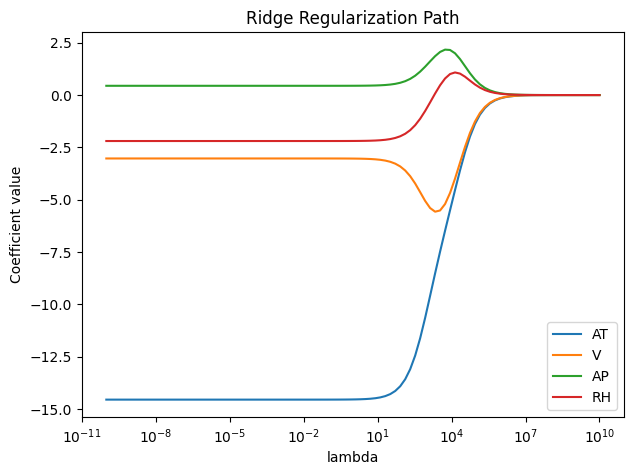

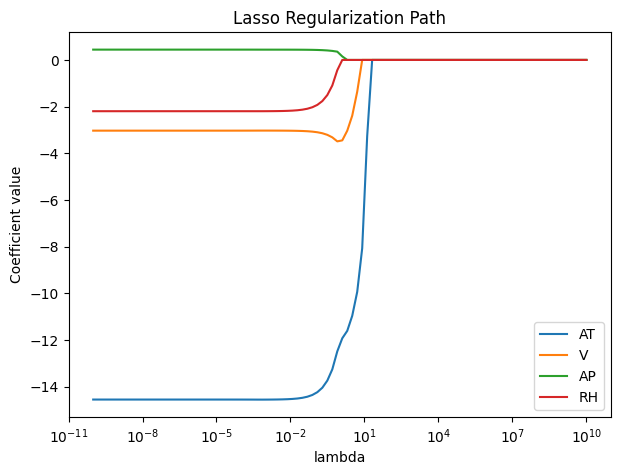

In [48]:
lambdas = np.logspace(-10, 10, 100)
X_scaled = scaler.fit_transform(X)
ridge_coefs = []

for lam in lambdas:
    ridge = Ridge(alpha=lam)
    ridge.fit(X_scaled, y)
    ridge_coefs.append(ridge.coef_)

ridge_coefs = np.array(ridge_coefs)
lasso_coefs = []

for lam in lambdas:
    lasso = Lasso(alpha=lam, max_iter=20000)
    lasso.fit(X_scaled, y)
    lasso_coefs.append(lasso.coef_)

lasso_coefs = np.array(lasso_coefs)

plt.figure(figsize=(7,5))
for i, feat in enumerate(feature_cols):
    plt.plot(lambdas, ridge_coefs[:, i], label=feat)

plt.xscale("log")
plt.xlabel("lambda")
plt.ylabel("Coefficient value")
plt.title("Ridge Regularization Path")
plt.legend()
plt.show()

plt.figure(figsize=(7,5))
for i, feat in enumerate(feature_cols):
    plt.plot(lambdas, lasso_coefs[:, i], label=feat)

plt.xscale("log")
plt.xlabel("lambda")
plt.ylabel("Coefficient value")
plt.title("Lasso Regularization Path")
plt.legend()
plt.show()


# Q5 Discussion
## What happens to coefficients as λ increases in Ridge vs Lasso?
- From the plots, as λ increases, Ridge regression shrinks all coefficients smoothly toward zero. The coefficients decrease continuously, but none of them become exactly zero. In contrast, Lasso regression shrinks some coefficients to zero evidently, while others shrinks inevidently, as λ increases. This results in only a portion of predictors is retained in the model.
## Which regression is better under multicollinearity in IVs, and why?
- Ridge regression is better under multicollinearity in IVs. Ridge shrinks all coefficients smoothly across correlated features, so it won't select one and shrink it first rather than arbitrarily selecting one. This leads to stable coefficient estimates and smoother coefficient paths as λ increases. Lasso tends to select one variable from a group of correlated predictors and set the others to zero, which is unstable.
## Which regression is better for feature selection, and why?
- Lasso regression is better for feature selection. Because Lasso can shrink coefficients exactly to zero for large λ, it effectively removes less important predictors from the model. This allows Lasso to perform feature selection automaticly, whereas Ridge regression retains all predictors in the model and therefore does not do feature selection automaticly.